In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("libraries loaded")

libraries loaded


In [5]:
df=pd.read_csv(r"C:\Users\HP5CD\Downloads\diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
df.describe()

Shape: (768, 9)

Column names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


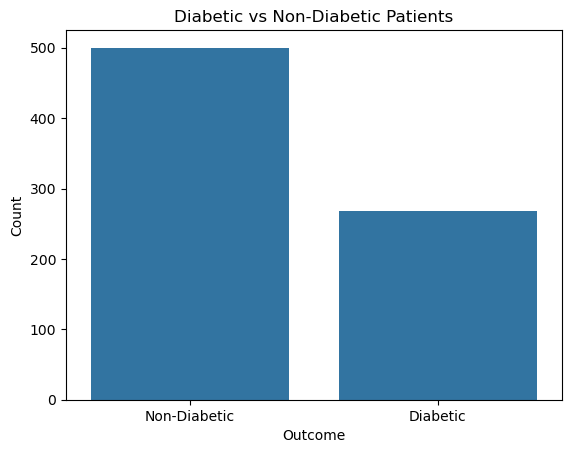

In [7]:
sns.countplot(x='Outcome', data=df)
plt.title('Diabetic vs Non-Diabetic Patients')
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.ylabel('Count')
plt.show()

Outcome
0    109.980000
1    141.257463
Name: Glucose, dtype: float64


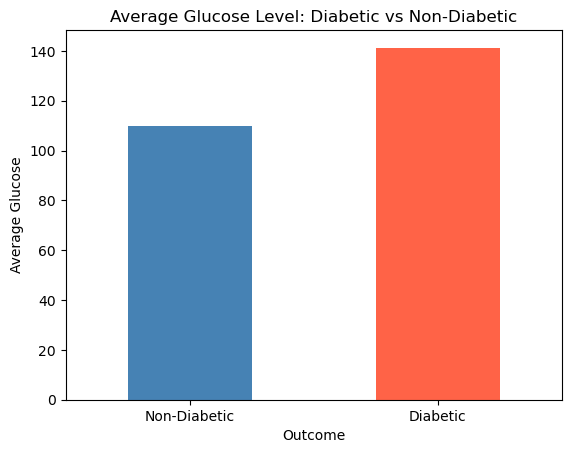

In [8]:
glucose_avg = df.groupby('Outcome')['Glucose'].mean()
print(glucose_avg)

glucose_avg.plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Average Glucose Level: Diabetic vs Non-Diabetic')
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'], rotation=0)
plt.ylabel('Average Glucose')
plt.show()

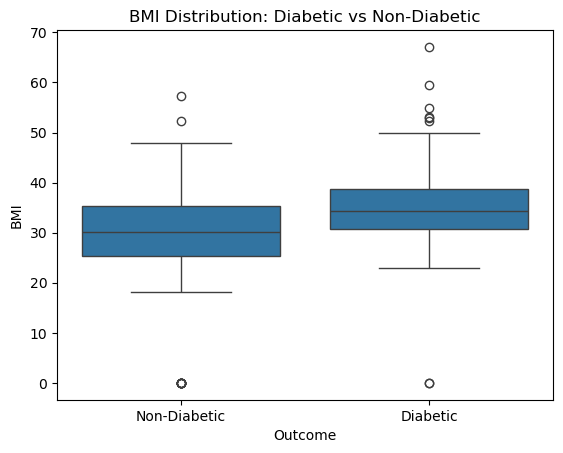

In [9]:
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title('BMI Distribution: Diabetic vs Non-Diabetic')
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.show()

## Key Finding 1: Glucose Levels
Diabetic patients show an average glucose level ~30 units higher than non-diabetic patients.
This aligns with glucose being a primary clinical indicator for diabetes diagnosis.


C:\Users\HP5CD\AppData\Local\Temp\ipykernel_36600\2527162819.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_diabetes = df.groupby('AgeGroup')['Outcome'].mean() * 100


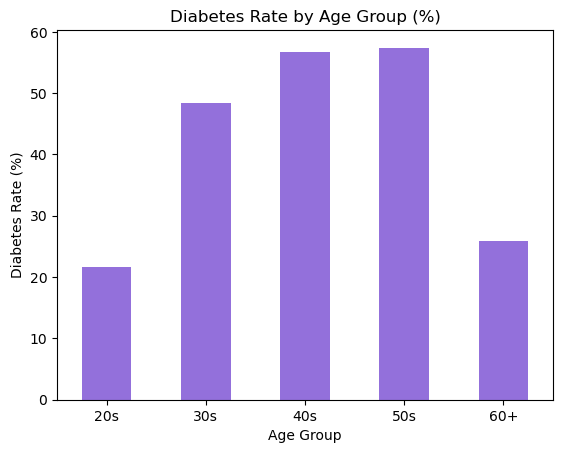

In [10]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 60, 100],
                         labels=['20s', '30s', '40s', '50s', '60+'])

age_diabetes = df.groupby('AgeGroup')['Outcome'].mean() * 100

age_diabetes.plot(kind='bar', color='mediumpurple')
plt.title('Diabetes Rate by Age Group (%)')
plt.ylabel('Diabetes Rate (%)')
plt.xlabel('Age Group')
plt.xticks(rotation=0)
plt.show()

## Key Finding 2: Age & Diabetes Risk
Patients in their 50s show the highest diabetes rate in this dataset.
This suggests diabetes risk increases with age, peaking in the 50s age group.

In [11]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zeros:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zero values ({round(zero_count/len(df)*100, 1)}%)")

Glucose: 5 zero values (0.7%)
BloodPressure: 35 zero values (4.6%)
SkinThickness: 227 zero values (29.6%)
Insulin: 374 zero values (48.7%)
BMI: 11 zero values (1.4%)


## Key Finding 3: Data Quality Issues
Several columns contain biologically impossible zero values, indicating missing data:
- Insulin: 48.7% zeros — nearly half the dataset is unreliable for this column
- SkinThickness: 29.6% zeros
- BloodPressure: 4.6% zeros

These are not true zeros — they represent missing measurements.
Any analysis using Insulin or SkinThickness should be treated with caution.

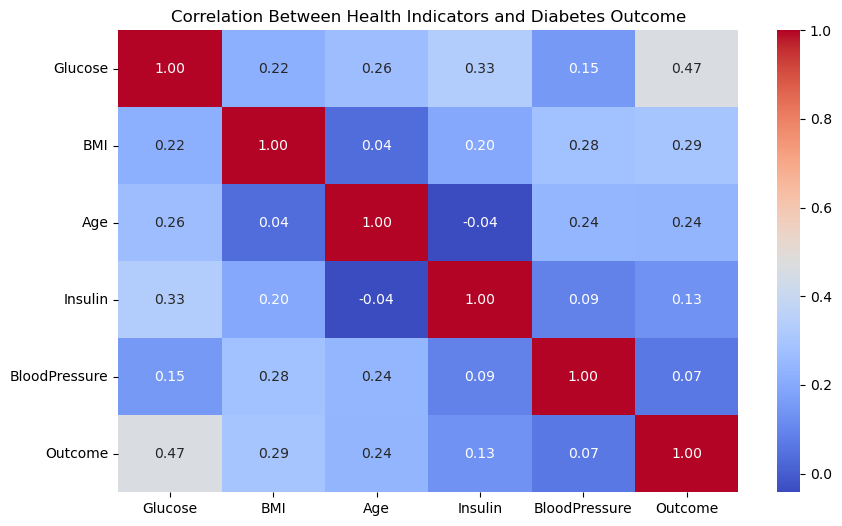

In [12]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[['Glucose', 'BMI', 'Age', 'Insulin', 
                 'BloodPressure', 'Outcome']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Health Indicators and Diabetes Outcome')
plt.show()

## Key Finding 4: Strongest Predictor
Glucose shows the highest correlation with diabetes outcome among all variables.
This is consistent with Findings 1 and clinical literature — glucose remains 
the most reliable indicator for diabetes diagnosis in this dataset.

In [ ]:
# Summary

This analysis explored the PIMA Indians Diabetes Dataset (768 patients) to identify 
patterns associated with diabetes.

*Key Findings:
1. Diabetic patients have ~30 units higher average glucose than non-diabetic patients
2. Diabetes rate peaks in the 50s age group
3. Nearly 50% of Insulin values are zero — a significant data quality issue
4. Glucose is the strongest predictor of diabetes outcome

*Tools used: Python, Pandas, Matplotlib, Seaborn  
*Dataset: PIMA Indians Diabetes Dataset (Kaggle)